# 02 · Liquidity Regime Classification


In [31]:
%pip install hmmlearn seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

DATA = "/Users/kylechan/Desktop/Microstructure_Factor_Decay Analysis Across_Liquidity_Regimes/data/master_metrics.csv"
df = pd.read_csv(DATA)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Log-transform skewed features
df["log_amihud"] = np.log(df["amihud"]              + 1e-9)
df["log_lambda"] = np.log(np.abs(df["kyle_lambda"]) + 1e-9)
df["log_spread"] = np.log(df["avg_spread"]          + 1e-9)

# Per-symbol z-score so mega-caps and small-caps are on the same scale
features = ["log_spread", "log_amihud", "log_lambda"]
for col in features:
    grp       = df.groupby("symbol")[col]
    df[col]   = (df[col] - grp.transform("mean")) / grp.transform("std")
    df[col]   = df[col].clip(-4, 4)

df = df.dropna(subset=features)
df_scaled = df[features].values
print(f"Scaled dataset: {len(df):,} rows")


Scaled dataset: 48,637 rows


In [33]:
# Fit 3-state Gaussian HMM
# 3 states chosen for economic interpretability: Abundant / Normal / Stressed
model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=1000,
    tol=1e-4,
    random_state=42,
)
model.fit(df_scaled)
print(f"✅ HMM fitted with 3 states")
print(f"Log-likelihood: {model.score(df_scaled):.2f}")


✅ HMM fitted with 3 states
Log-likelihood: -163272.06


In [34]:
# Label regimes by raw amihud mean (not z-scored) — unambiguous ordering
df["regime_raw"] = model.predict(df_scaled)

raw_amihud_by_state = df.groupby("regime_raw")["amihud"].mean()
rank = raw_amihud_by_state.rank().astype(int)  # 1=most liquid, 3=most illiquid

label_map = {}
for state, r in rank.items():
    if r == 1:   label_map[state] = "Abundant"
    elif r == 3: label_map[state] = "Stressed"
    else:        label_map[state] = "Normal"

df["regime_label"] = df["regime_raw"].map(label_map)
encode = {"Abundant": 0, "Normal": 1, "Stressed": 2}
df["regime"] = df["regime_label"].map(encode)

print("Regime counts:")
print(df["regime_label"].value_counts())


Regime counts:
regime_label
Abundant    25132
Normal      19028
Stressed     4477
Name: count, dtype: int64


In [35]:
# Regime personality table
regime_stats = df.groupby("regime_label")[["avg_spread", "amihud", "kyle_lambda"]].mean()
regime_stats["counts"] = df["regime_label"].value_counts()
print("--- Regime Personalities ---")
display(regime_stats)


--- Regime Personalities ---


,avg_spread,amihud,kyle_lambda,counts
regime_label,,,,
Abundant,0.149199,0.006755,0.001999,25132
Normal,0.320938,0.016286,0.005031,19028
Stressed,0.399224,0.026669,0.012565,4477


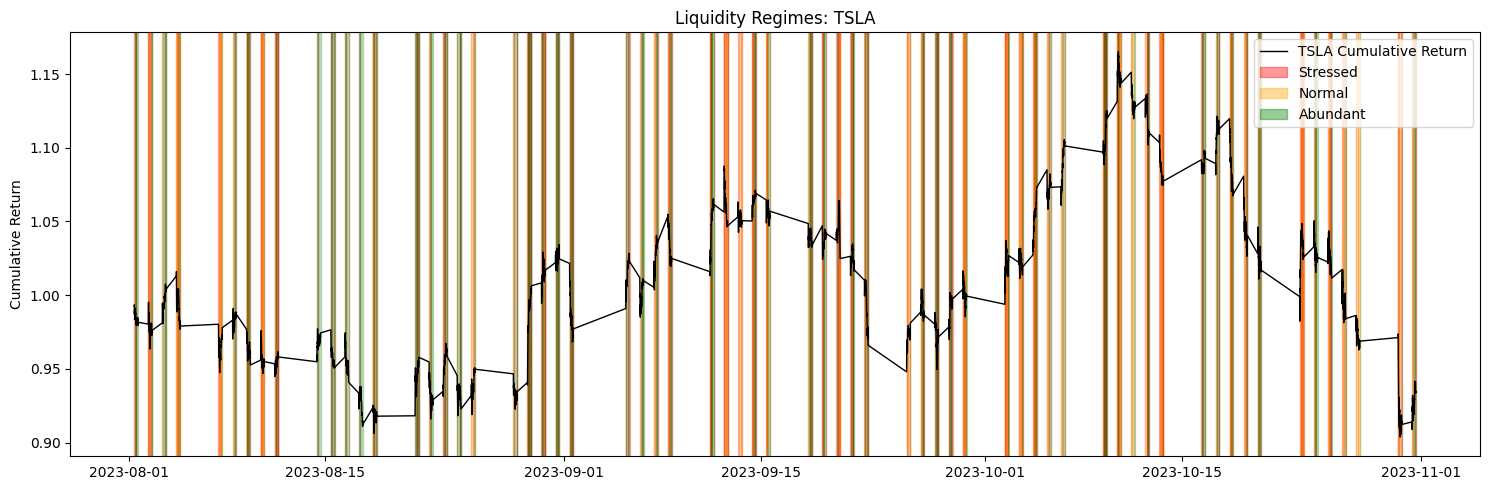

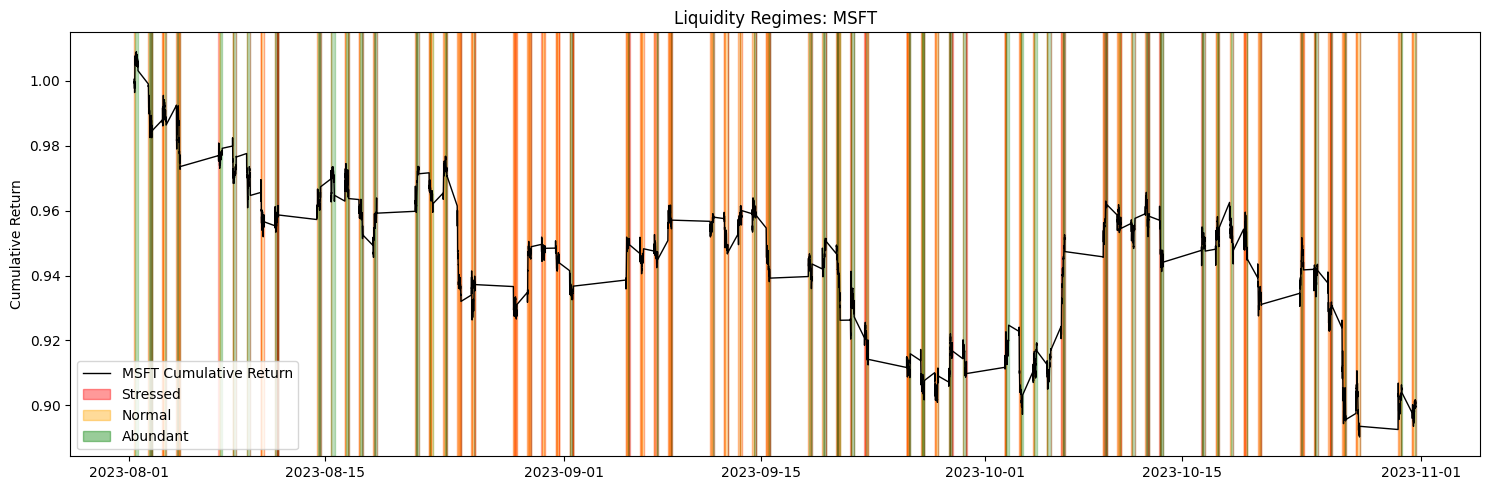

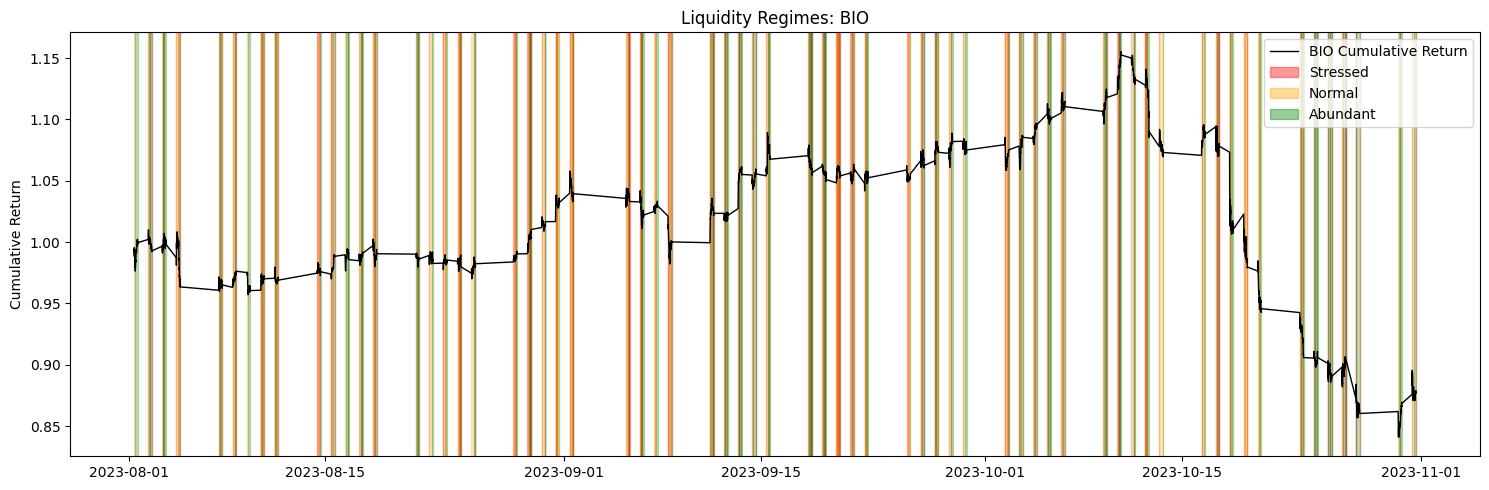

In [36]:
# Price path visualisation with regime shading
def plot_regimes_for_ticker(df, ticker):
    plot_df = df[df["symbol"] == ticker].copy()
    plot_df["ts_recv"] = pd.to_datetime(plot_df["ts_recv"])
    plot_df = plot_df.sort_values("ts_recv")

    color_map = {"Stressed": "red", "Normal": "orange", "Abundant": "green"}

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(plot_df["ts_recv"], (1 + plot_df["return"]).cumprod(),
            color="black", linewidth=1, label=f"{ticker} Cumulative Return")

    # Break at day boundaries AND regime changes to avoid overnight spans
    plot_df["date"]         = plot_df["ts_recv"].dt.date
    plot_df["regime_change"] = (
        plot_df["regime_label"].ne(plot_df["regime_label"].shift()) |
        plot_df["date"].ne(plot_df["date"].shift())
    )
    plot_df["block"] = plot_df["regime_change"].cumsum()

    for _, block in plot_df.groupby("block"):
        lbl   = block["regime_label"].iloc[0]
        start = block["ts_recv"].iloc[0]
        end   = block["ts_recv"].iloc[-1] + pd.Timedelta(minutes=5)
        ax.axvspan(start, end, color=color_map[lbl], alpha=0.25)

    from matplotlib.patches import Patch
    handles = [ax.lines[0]] + [Patch(color=c, alpha=0.4, label=l)
                                for l, c in color_map.items()]
    ax.legend(handles=handles)
    plt.title(f"Liquidity Regimes: {ticker}")
    plt.ylabel("Cumulative Return")
    plt.tight_layout()
    plt.show()

plot_regimes_for_ticker(df, "TSLA")
plot_regimes_for_ticker(df, "MSFT")
plot_regimes_for_ticker(df, "BIO")


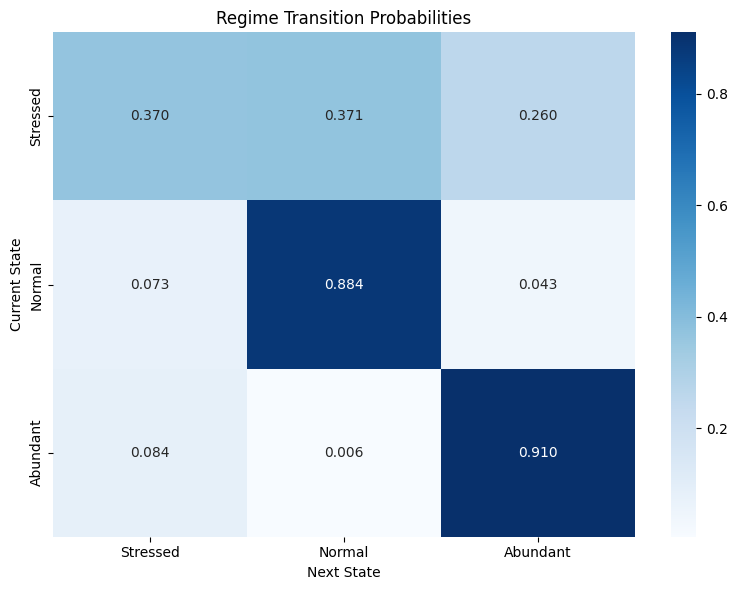

In [37]:
import seaborn as sns

# Transition matrix — shows regime persistence ("stickiness")
trans_mtx = pd.DataFrame(
    model.transmat_,
    index=list(label_map.values()),
    columns=list(label_map.values()),
)

plt.figure(figsize=(8, 6))
sns.heatmap(trans_mtx, annot=True, fmt=".3f", cmap="Blues")
plt.title("Regime Transition Probabilities")
plt.ylabel("Current State")
plt.xlabel("Next State")
plt.tight_layout()
plt.show()


In [38]:
OUT = "/Users/kylechan/Desktop/Microstructure_Factor_Decay Analysis Across_Liquidity_Regimes/data/master_metrics_with_regimes.csv"
df.to_csv(OUT, index=False)
print(f"✅ Phase 2 complete → {OUT}")


✅ Phase 2 complete → /Users/kylechan/Desktop/Microstructure_Factor_Decay Analysis Across_Liquidity_Regimes/data/master_metrics_with_regimes.csv
